In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="")
project = rf.workspace("mohamed-traore-2ekkp").project("chest-x-rays-qjmia")
version = project.version(4)
dataset = version.download("folder")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 45.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Chest-X-Rays-4 in folder:: 100%|██████████| 13987/13987 [00:01<00:00, 6995.05it/s]


In [2]:
!ls
!ls "Chest-X-Rays-4"
!find "Chest-X-Rays-4" -maxdepth 2 -type d

Chest-X-Rays-4	sample_data
README.dataset.txt  README.roboflow.txt  test  train  valid
Chest-X-Rays-4
Chest-X-Rays-4/valid
Chest-X-Rays-4/valid/PNEUMONIA
Chest-X-Rays-4/valid/NORMAL
Chest-X-Rays-4/test
Chest-X-Rays-4/test/PNEUMONIA
Chest-X-Rays-4/test/NORMAL
Chest-X-Rays-4/train
Chest-X-Rays-4/train/PNEUMONIA
Chest-X-Rays-4/train/NORMAL


In [3]:
import os
import random
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, AveragePooling2D, MaxPooling2D,
    Flatten, Dense, Dropout, BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [4]:
train_dir = "/content/Chest-X-Rays-4/train"
valid_dir = "/content/Chest-X-Rays-4/valid"
test_dir  = "/content/Chest-X-Rays-4/test"

print("train_dir exists:", os.path.exists(train_dir))
print("valid_dir exists:", os.path.exists(valid_dir))
print("test_dir exists :", os.path.exists(test_dir))

!ls -lah "{train_dir}" | head -n 20
!ls -lah "{valid_dir}" | head -n 20
!ls -lah "{test_dir}"  | head -n 20

train_dir exists: True
valid_dir exists: True
test_dir exists : True
total 1.4M
drwxr-xr-x 4 root root 4.0K Jan 28 08:42 .
drwxr-xr-x 5 root root 4.0K Jan 28 08:42 ..
drwxr-xr-x 2 root root 356K Jan 28 08:42 NORMAL
drwxr-xr-x 2 root root 972K Jan 28 08:42 PNEUMONIA
total 140K
drwxr-xr-x 4 root root 4.0K Jan 28 08:42 .
drwxr-xr-x 5 root root 4.0K Jan 28 08:42 ..
drwxr-xr-x 2 root root  36K Jan 28 08:42 NORMAL
drwxr-xr-x 2 root root  96K Jan 28 08:42 PNEUMONIA
total 84K
drwxr-xr-x 4 root root 4.0K Jan 28 08:42 .
drwxr-xr-x 5 root root 4.0K Jan 28 08:42 ..
drwxr-xr-x 2 root root  20K Jan 28 08:42 NORMAL
drwxr-xr-x 2 root root  48K Jan 28 08:42 PNEUMONIA


In [5]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=SEED
)

val_gen = test_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class indices:", train_gen.class_indices)
print("Train samples:", train_gen.samples, "Val samples:", val_gen.samples, "Test samples:", test_gen.samples)


Found 12229 images belonging to 2 classes.
Found 1165 images belonging to 2 classes.
Found 582 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Train samples: 12229 Val samples: 1165 Test samples: 582


Batch X shape: (32, 224, 224, 3)
Batch y shape: (32,)
First 10 labels: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


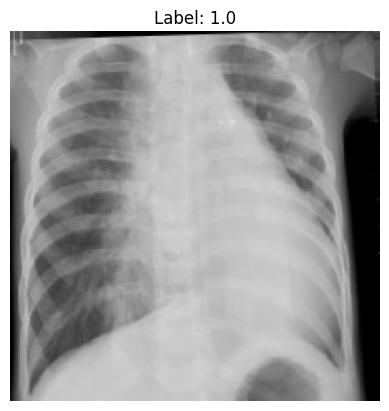

In [6]:

import matplotlib.pyplot as plt

x_batch, y_batch = next(train_gen)
print("Batch X shape:", x_batch.shape)
print("Batch y shape:", y_batch.shape)
print("First 10 labels:", y_batch[:10])

plt.figure()
plt.imshow(x_batch[0])
plt.title(f"Label: {y_batch[0]}")
plt.axis("off")
plt.show()


In [7]:

from collections import Counter

counts = Counter(train_gen.classes)
print("Train class counts:", counts)

total = sum(counts.values())
class_weight = {cls: total/(2*cnt) for cls, cnt in counts.items()}
print("Computed class_weight:", class_weight)


Train class counts: Counter({np.int32(1): 8917, np.int32(0): 3312})
Computed class_weight: {np.int32(0): 1.846165458937198, np.int32(1): 0.6857126836379949}


In [8]:


baseline_model = Sequential([
    Conv2D(
        filters=16,
        kernel_size=(5, 5),
        strides=(5, 5),
        activation="relu",
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    ),
    AveragePooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

baseline_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()


Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 44, 44, 16)     │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 22, 22, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7744)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       495,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 496,961 (1.90 MB)

 Trainable params: 496,961 (1.90 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:


improved_model = Sequential([
    Conv2D(32, (3,3), padding="same", activation="relu",
           input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),
    Dropout(0.4),

    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

improved_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

improved_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,465 (400.25 KB)

 Trainable params: 102,017 (398.50 KB)

 Non-trainable params: 448 (1.75 KB)

In [10]:

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True)
]


In [11]:

EPOCHS = 25

history_baseline = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight
)


Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.


Epoch 1/25
383/383 ━━━━━━━━━━━━━━━━━━━━ 164s 419ms/step - accuracy: 0.7068 - loss: 0.5313 - val_accuracy: 0.9253 - val_loss: 0.2106 - learning_rate: 0.0010
Epoch 2/25
383/383 ━━━━━━━━━━━━━━━━━━━━ 145s 379ms/step - accuracy: 0.8525 - loss: 0.3372 - val_accuracy: 0.9330 - val_loss: 0.1784 - learning_rate: 0.0010
Epoch 3/25
383/383 ━━━━━━━━━━━━━━━━━━━━ 143s 373ms/step - accuracy: 0.8711 - loss: 0.3074 - val_accuracy: 0.9339 - val_loss: 0.1779 - learning_rate: 0.0010
Epoch 4/25
383/383 ━━━━━━━━━━━━━━━━━━━━ 140s 366ms/step - accuracy: 0.8791 - loss: 0.2831 - val_accuracy: 0.8635 - val_loss: 0.3253 - learning_rate: 0.0010
Epoch 5/25
383/383 ━━━━━━━━━━━━━━━━━━━━ 139s 362ms/step - accuracy: 0.8939 - loss: 0.2555 - val_accuracy: 0.8721 - val_loss: 0.2937 - learning_rate: 0.0010
Epoch 6/25
383/383 ━━━━━━━━━━━━━━━━━━━━ 139s 363ms/step - accuracy: 0.9057 - loss: 0.2330 - val_accuracy: 0.9476 - val_loss: 0.1416 - learning_rate: 5.0000e-04
Epoch 7/25
383/383 ━━━━━━━━━━━━━━━━━━━━ 140s 366ms/step - ac

In [12]:
history_improved = improved_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight
)

Epoch 1/25
383/383 ━━━━━━━━━━━━━━━━━━━━ 184s 457ms/step - accuracy: 0.7753 - loss: 0.4448 - val_accuracy: 0.7391 - val_loss: 1.3414 - learning_rate: 0.0010
Epoch 2/25
383/383 ━━━━━━━━━━━━━━━━━━━━ 167s 436ms/step - accuracy: 0.8334 - loss: 0.3567 - val_accuracy: 0.6635 - val_loss: 0.5901 - learning_rate: 0.0010
Epoch 3/25
383/383 ━━━━━━━━━━━━━━━━━━━━ 168s 440ms/step - accuracy: 0.8568 - loss: 0.3164 - val_accuracy: 0.4240 - val_loss: 1.3190 - learning_rate: 0.0010
Epoch 4/25
383/383 ━━━━━━━━━━━━━━━━━━━━ 169s 442ms/step - accuracy: 0.8845 - loss: 0.2778 - val_accuracy: 0.7373 - val_loss: 0.6546 - learning_rate: 0.0010
Epoch 5/25
383/383 ━━━━━━━━━━━━━━━━━━━━ 168s 439ms/step - accuracy: 0.9020 - loss: 0.2455 - val_accuracy: 0.9116 - val_loss: 0.2168 - learning_rate: 5.0000e-04
Epoch 6/25
383/383 ━━━━━━━━━━━━━━━━━━━━ 167s 435ms/step - accuracy: 0.9097 - loss: 0.2248 - val_accuracy: 0.2627 - val_loss: 15.3808 - learning_rate: 5.0000e-04
Epoch 7/25
383/383 ━━━━━━━━━━━━━━━━━━━━ 167s 435ms/step

In [13]:

from sklearn.metrics import confusion_matrix, classification_report,
accuracy_score, precision_recall_fscore_support

def evaluate_binary(model, generator, name, threshold=0.5):
    y_prob = model.predict(generator).ravel()
    y_pred = (y_prob >= threshold).astype(int)
    y_true = generator.classes

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary")
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n===== {name} =====")
    print("Accuracy :", acc)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-score :", f1)
    print("\nConfusion Matrix:\n", cm)

    print("\nClassification Report:\n",
          classification_report(
              y_true, y_pred,
              target_names=list(generator.class_indices.keys())
          )
    )

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ConfusionMatrix": cm
    }


In [14]:

baseline_results = evaluate_binary(baseline_model, test_gen, "Baseline")
improved_results = evaluate_binary(improved_model, test_gen, "Improved")


19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 248ms/step

===== Baseline =====
Accuracy : 0.9278350515463918
Precision: 0.9624060150375939
Recall   : 0.9343065693430657
F1-score : 0.9481481481481482

Confusion Matrix:
 [[156  15]
 [ 27 384]]

Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.85      0.91      0.88       171
   PNEUMONIA       0.96      0.93      0.95       411

    accuracy                           0.93       582
   macro avg       0.91      0.92      0.91       582
weighted avg       0.93      0.93      0.93       582

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step

===== Improved =====
Accuracy : 0.9398625429553265
Precision: 0.9372093023255814
Recall   : 0.9805352798053528
F1-score : 0.9583828775267539

Confusion Matrix:
 [[144  27]
 [  8 403]]

Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.95      0.84      0.89       171
   PNEUMONIA       0.94      0.98      0.96       411

    acc

In [15]:

import pandas as pd

results_df = pd.DataFrame([
    {k: baseline_results[k] for k in ["Model","Accuracy","Precision","Recall","F1"]},
    {k: improved_results[k] for k in ["Model","Accuracy","Precision","Recall","F1"]}
])

results_df


,Model,Accuracy,Precision,Recall,F1
0,Baseline,0.927835,0.962406,0.934307,0.948148
1,Improved,0.939863,0.937209,0.980535,0.958383


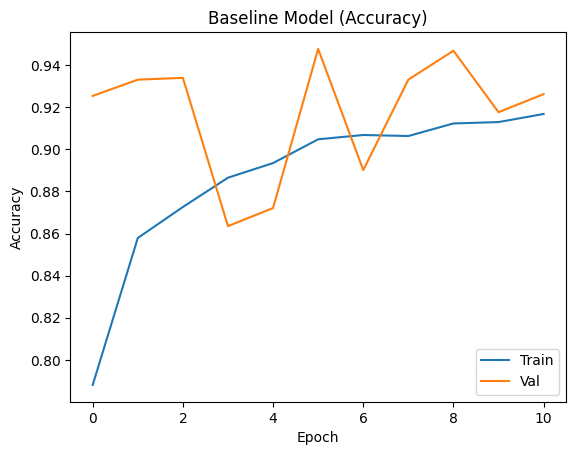

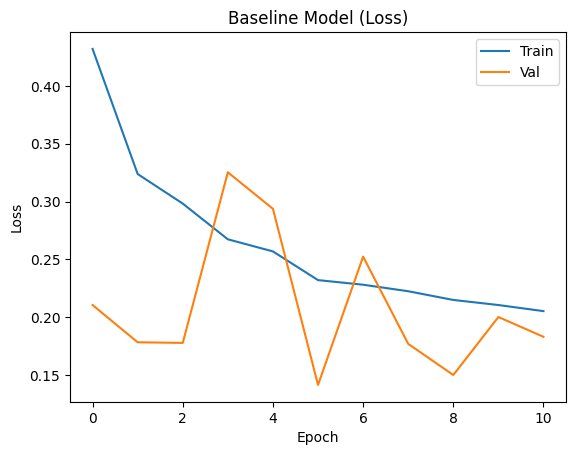

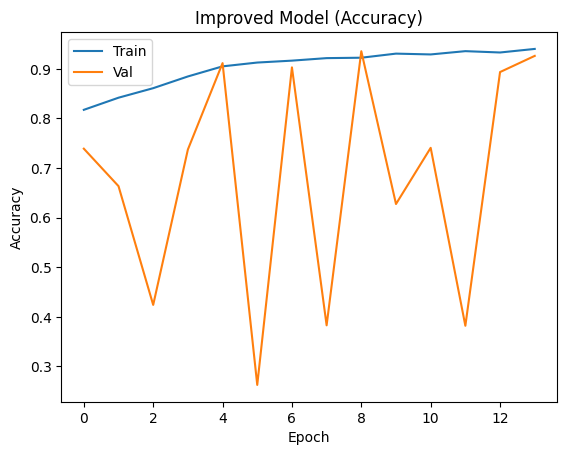

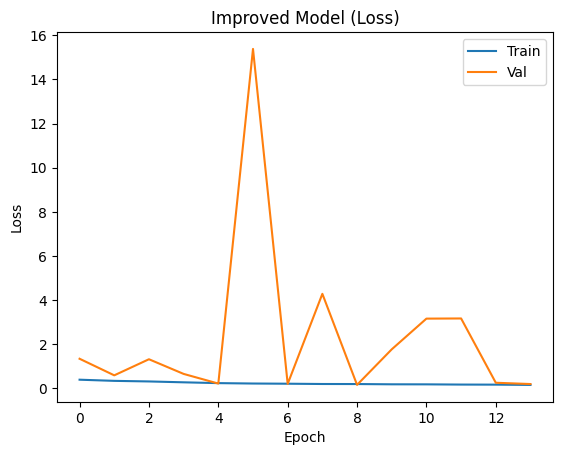

In [16]:

def plot_history(history, title="Training Curves"):
    plt.figure()
    plt.plot(history.history["accuracy"])
    plt.plot(history.history["val_accuracy"])
    plt.title(title + " (Accuracy)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(["Train", "Val"])
    plt.show()

    plt.figure()
    plt.plot(history.history["loss"])
    plt.plot(history.history["val_loss"])
    plt.title(title + " (Loss)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(["Train", "Val"])
    plt.show()

plot_history(history_baseline, "Baseline Model")
plot_history(history_improved, "Improved Model")


In [17]:

baseline_model.save("baseline_model.keras")
improved_model.save("improved_model.keras")
print("Saved: baseline_model.keras, improved_model.keras")


Saved: baseline_model.keras, improved_model.keras
